In [3]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *

In [4]:
file_path = f'/Users/kellyhui/Downloads/RBG_data/4_3_26/KH_RBG_otr_040326_PT_P6_post_anc.csv'
df = pd.read_csv(f'{file_path}') 
df_anc = clean_and_transpose(df, 25, 63).dropna().transpose()
df_anc = df_anc.reset_index()
df_anc.columns = ['Well', 'OD']
df_anc

def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)
    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD']]

tidy_anc = tidy_plate(df_anc, 7)
bio_rep_anc = tidy_anc.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() 

In [5]:
dataframes = []
for i in range(1, 7):
    file_path = f'/Users/kellyhui/Downloads/RBG_data/4_3_26/KH_RBG_otr_040326_PT_P6_post_{i}.csv'
    df = pd.read_csv(f'{file_path}') 
    df = clean_and_transpose(df, 24, 122).dropna().transpose()
    df = df.reset_index()
    df.columns = ['Well', 'OD']
    dataframes.append(df)

#assign phage doses
def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)

    H_mean = df[df['BioRep'] == 'H']['OD'].mean()
    print(H_mean)
    df['OD_subtracted'] = df['OD'] - H_mean

    df = df[df['BioRep'] != 'H']

    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD', 'OD_subtracted']]

tbl_arr = [tidy_plate(dataframes[i], i+1) for i in range(6)]
tbl_arr.append(tidy_anc)

0.20410833375
0.22640833500000002
0.17144166849999998
0.22721666716666666
0.15735000058333334
0.11445833224999998


In [6]:
for i, df in enumerate(dataframes):
    df.to_csv(f"PT_P6_{i}.csv", index=False)

In [7]:
#group plate, biol rep, and dose
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
bio_rep_mean[0].head(6)

,Plate,BioRep,Dose,OD
0,1,A,0.0,0.484367
1,1,A,10000.0,0.445233
2,1,A,1000000.0,0.437033
3,1,A,100000000.0,0.459467
4,1,B,0.0,0.355133
5,1,B,10000.0,0.323600


In [8]:
#So each plate is a different glycerol stock/population, and each row has 7 populations
#I need a dose response for each plate
#So I can take my old dose resposne curves and do it here
#then ill have 7 ic50 values for each plate, and somehow I can group them all into one graph maybe? combine it with the pre-passaging ic50 histogram.

# Strain level 

In [9]:
from scipy.stats import linregress

results = []

for df in tbl_arr:

    df = df.copy()

    # log-transform dose (avoid 0 issue)
    #df = df[df["Dose"] > 0]
    df["Dose_log"] = np.log10(df["Dose"] + 0.01)

    for (plate, bio), group in df.groupby(["Plate", "BioRep"]):

        x = group["Dose_log"].values
        y = group["OD"].values   # or OD if preferred

        if len(x) < 2:
            continue

        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r2 = r_value**2

        results.append({
            "Plate": plate,
            "BioRep": bio,
            "R2": r2,
            "p_value": p_value,
            "n_points": len(x)
        })


r2_table = pd.DataFrame(results)

r2_table.head(3)

,Plate,BioRep,R2,p_value,n_points
0,1,A,0.282816,0.075143,12
1,1,B,0.129804,0.249971,12
2,1,C,0.071440,0.400995,12


# Population Level

In [10]:
plate_results = []

for df in tbl_arr:
    df = df.copy()

    # log transform (handle 0)
    df["Dose_log"] = np.log10(df["Dose"] + 0.01)

    x = df["Dose_log"].values
    y = df["OD"].values

    if len(x) < 2:
        continue

    slope, intercept, r_value, p_value, _ = linregress(x, y)

    plate_results.append({
        "Plate": df["Plate"].iloc[0],
        "R2": r_value**2,
        "p_value": p_value,
        "slope": slope
    })

plate_table = pd.DataFrame(plate_results)
plate_table 

,Plate,R2,p_value,slope
0,1,0.018056,2.229864e-01,0.002473
1,2,0.000033,9.584715e-01,0.000068
2,3,0.013987,2.839716e-01,-0.001482
3,4,0.003360,6.004382e-01,-0.001130
4,5,0.041256,6.387383e-02,-0.003792
5,6,0.008313,4.094706e-01,0.001078
6,7,0.830315,1.188248e-14,-0.023978


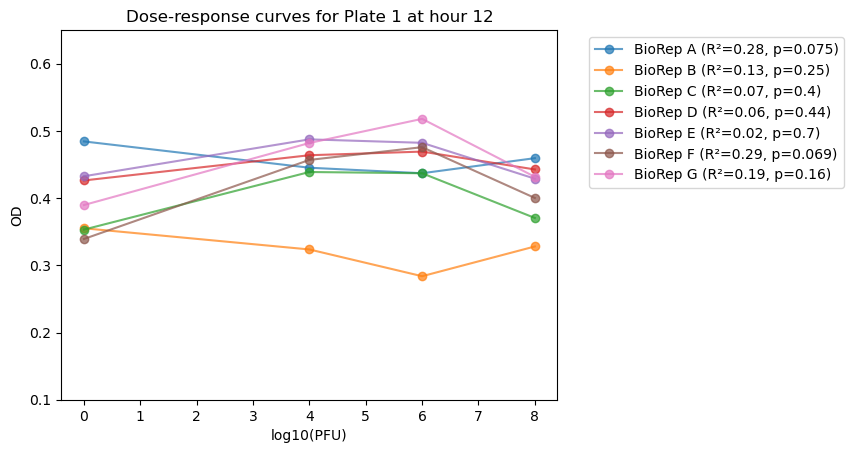

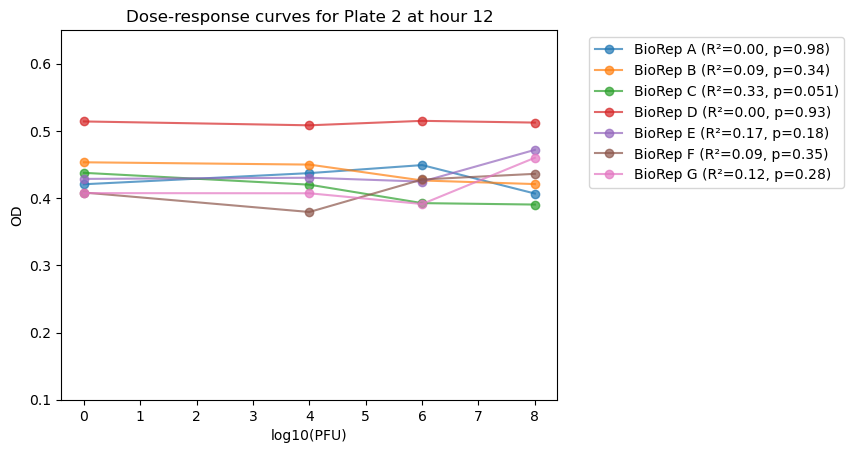

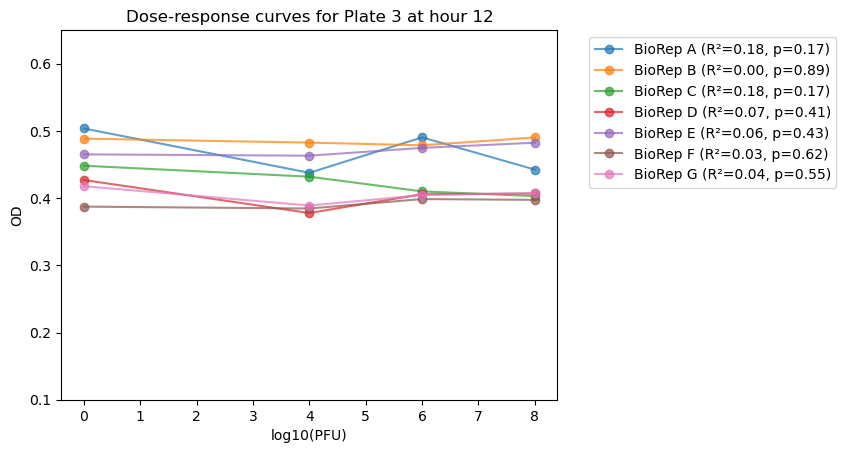

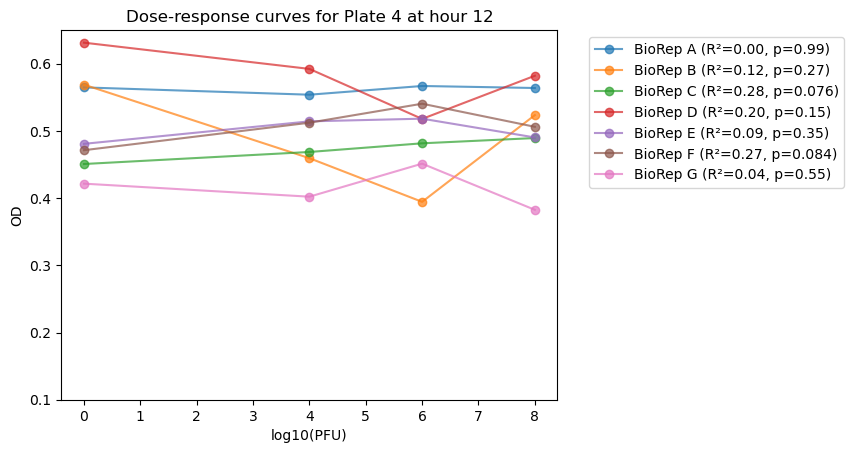

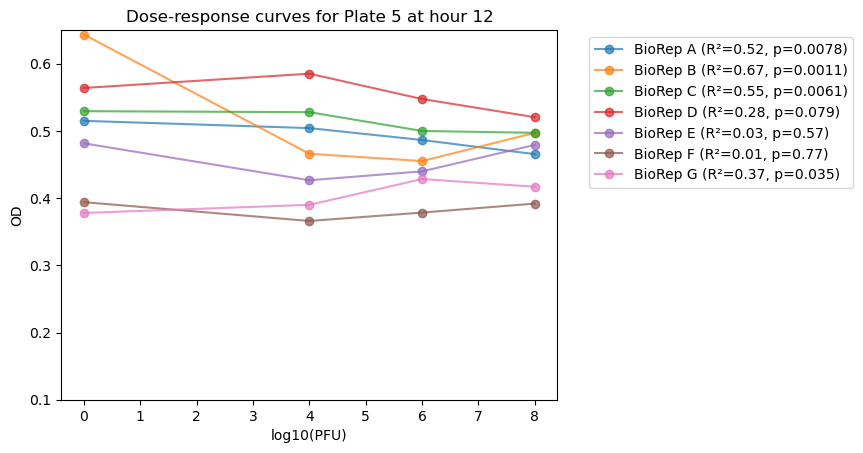

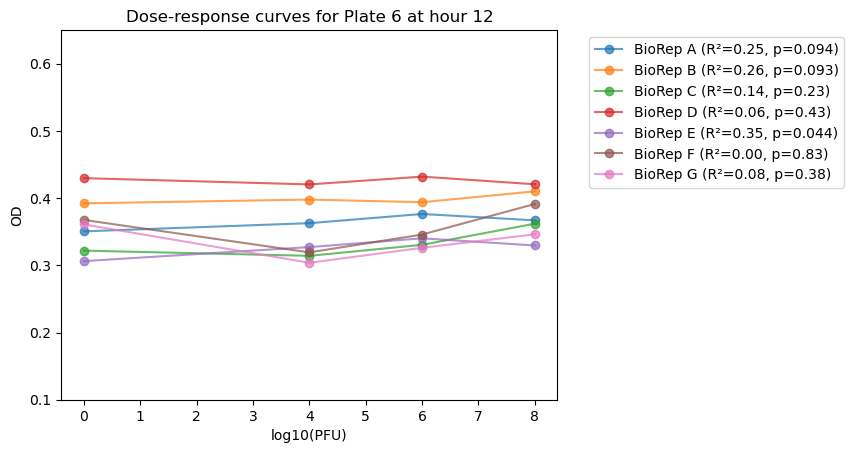

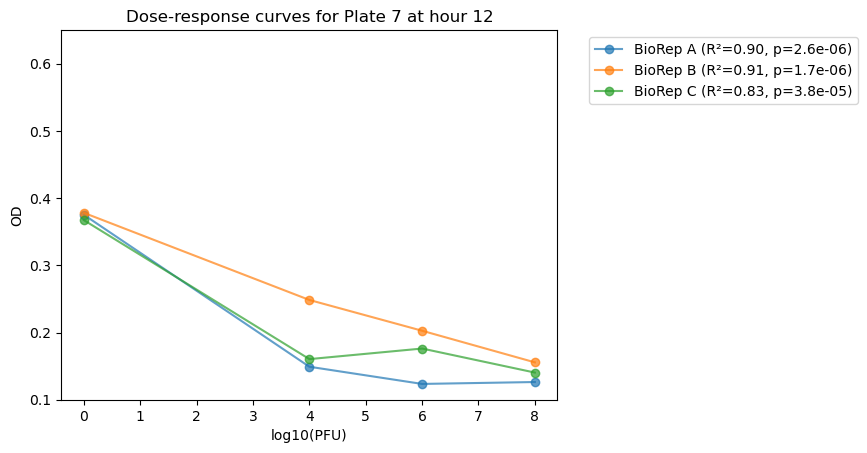

In [11]:
for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    # get R² for THIS plate
    r_df = r2_table[r2_table['Plate'] == (i + 1)]

    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        # safely get R²
        match = r_df[r_df['BioRep'] == bio]

        if len(match) == 0:
            r2 = np.nan
            p = np.nan
        else:
            r2 = match['R2'].values[0]
            p = match['p_value'].values[0]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.7,
            label=f'BioRep {bio} (R²={r2:.2f}, p={p:.2g})'
        )

    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(f'Dose-response curves for Plate {i+1} at hour 12')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 0.65)
    plt.show()

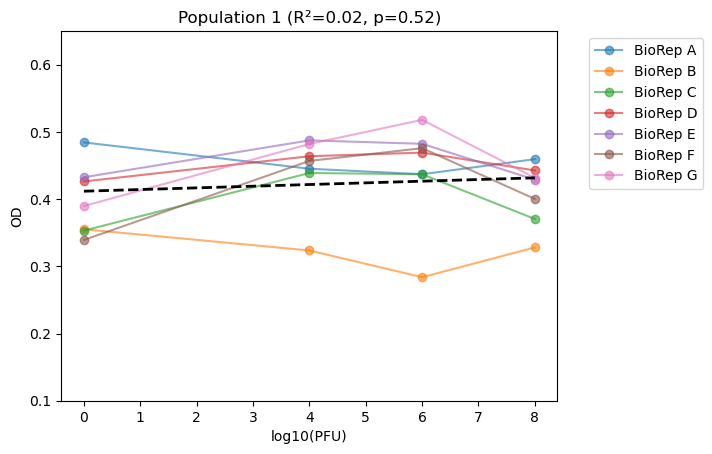

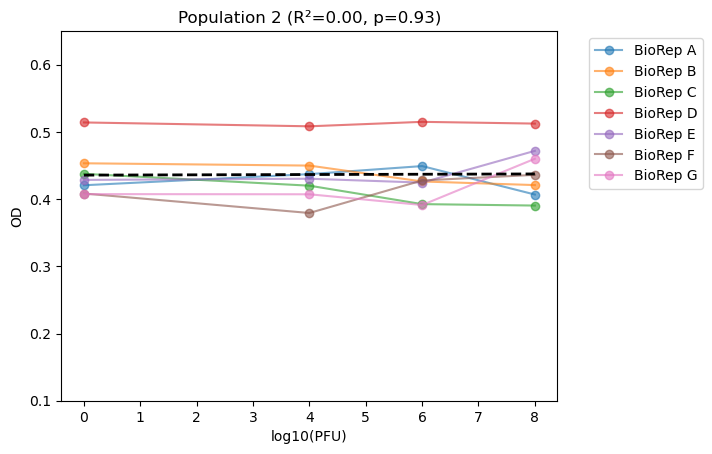

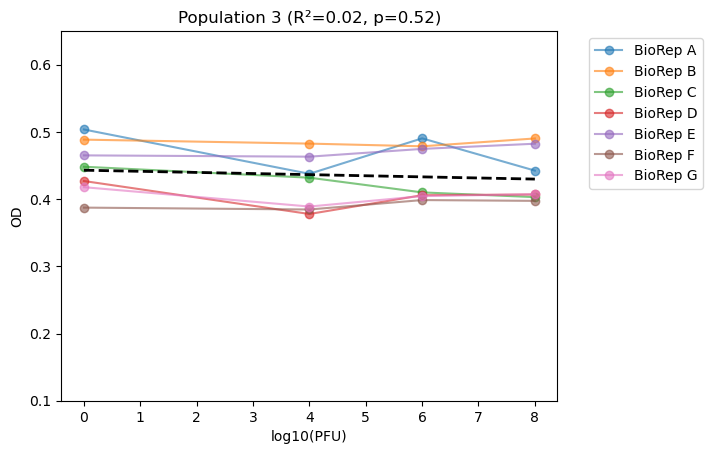

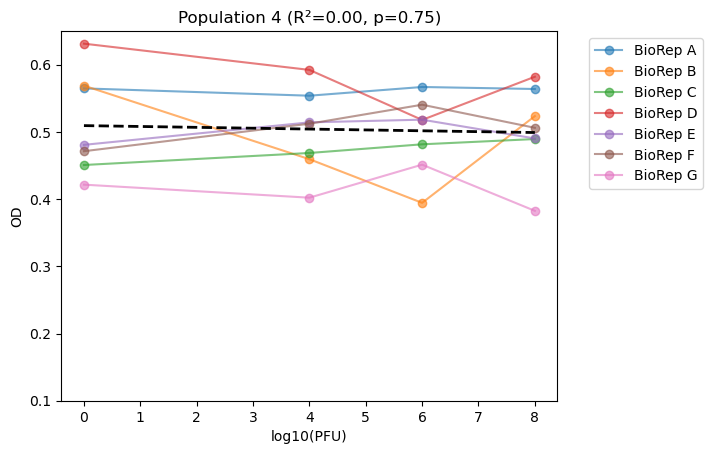

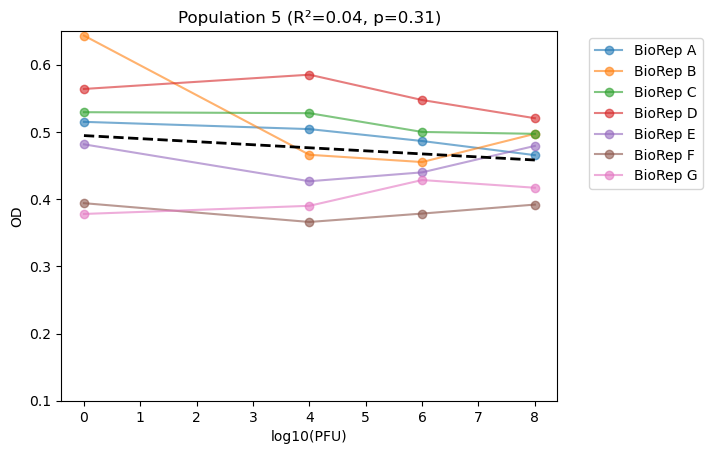

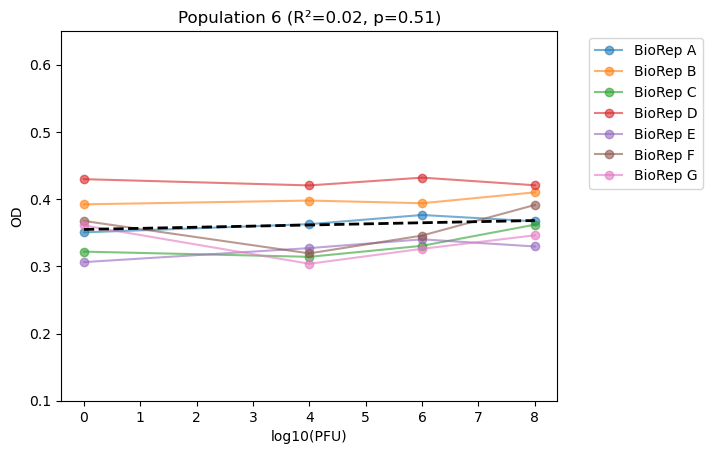

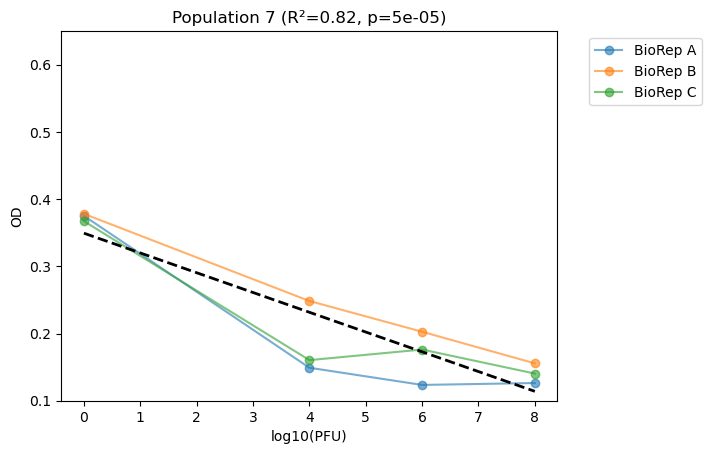

In [12]:
from scipy.stats import linregress
import numpy as np

for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    x_all = df['Dose_plot'].values
    y_all = df['OD'].values

    slope, intercept, r_value, p_value, _ = linregress(x_all, y_all)
    r2 = r_value**2

    #plot each BioRep
    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.6,
            label=f'BioRep {bio}'
        )


    #plot the regression line
    x_line = np.linspace(min(x_all), max(x_all), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', linewidth=2, color='black')

    # --- labels ---
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(
        f'Population {i+1} (R²={r2:.2f}, p={p_value:.2g})'
    )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 0.65)

    plt.show()

In [13]:
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
combined_df = pd.concat(bio_rep_mean, ignore_index=True)
combined_df = combined_df[combined_df['Plate'] != 6]
variance_summary = (
    combined_df
    .groupby(['Plate', 'Dose'])
    .agg(
        mean_OD=('OD', 'mean'),
        variance_OD=('OD', 'var'),
        sd_OD=('OD', 'std')
    )
    .reset_index()
)

variance_summary['CV'] = (
    variance_summary['sd_OD'] /
    variance_summary['mean_OD']
)

variance_summary['CV'].mean()

np.float64(0.12623006904690362)

R^2 Plots

# ------ IC50 is no longer a good metric! -------

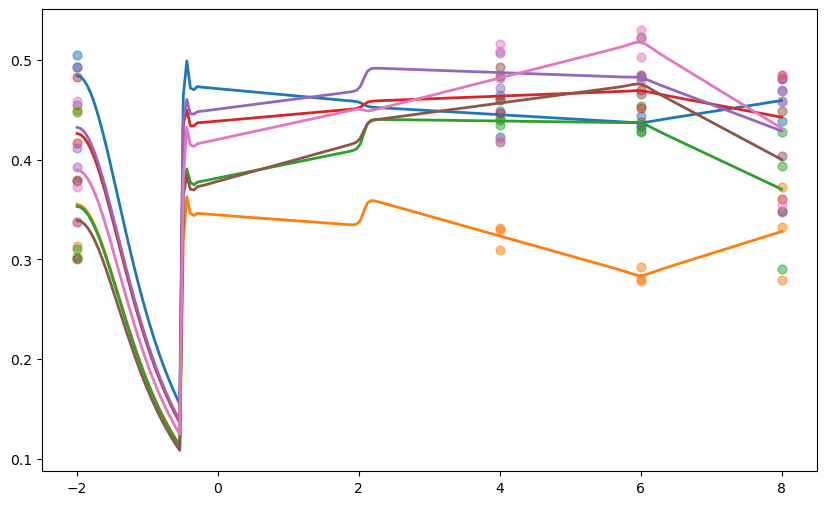

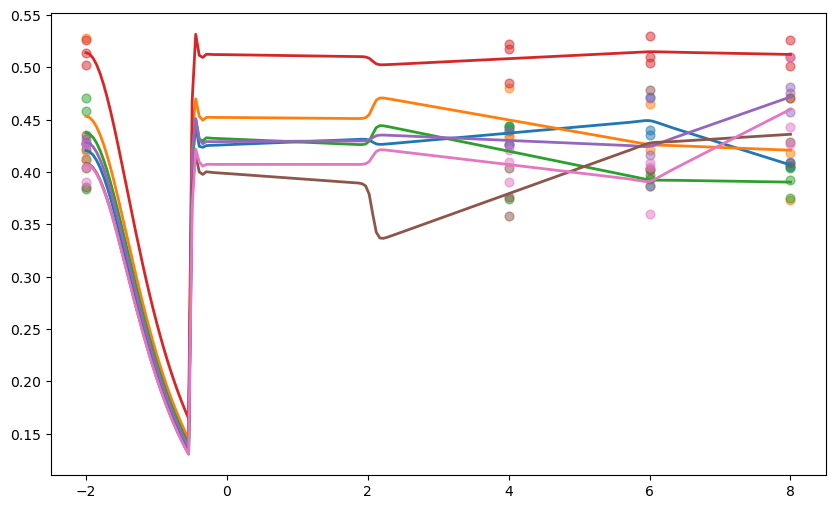

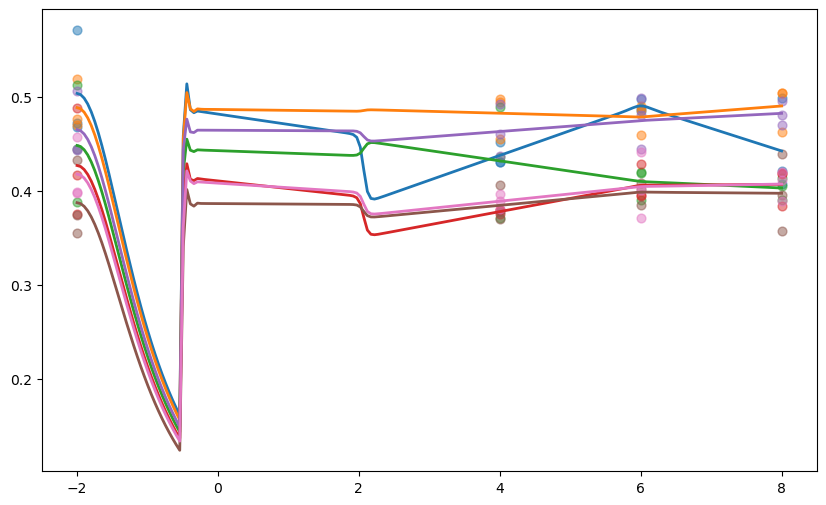

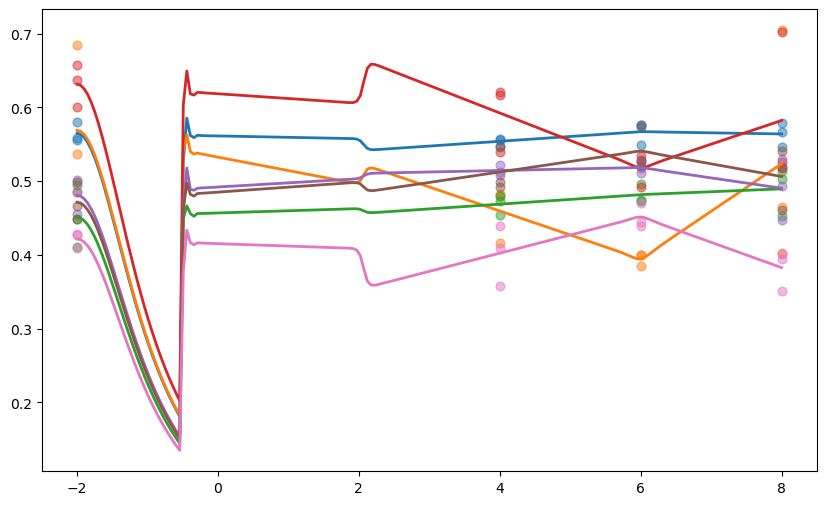

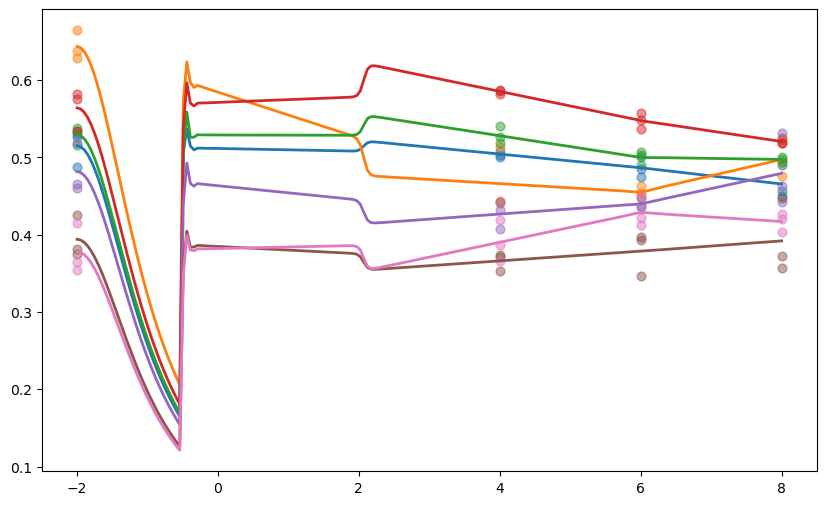

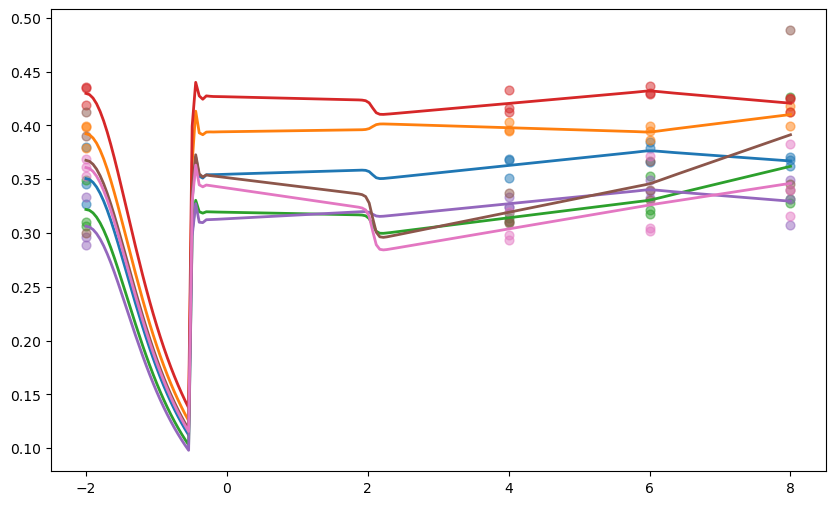

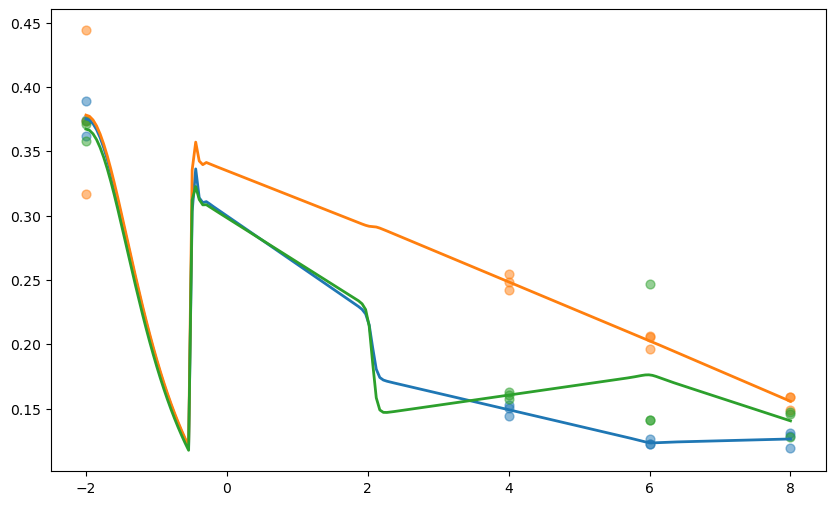

In [39]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
from scipy.interpolate import interp1d

bio_reps = tbl_arr[0]['BioRep'].unique()
plates = range(len(tbl_arr))

for plate in plates:
    
    plate_df = tbl_arr[plate]
    plt.figure(figsize=(10,6))
    
    for bio in bio_reps:
        bio_df = plate_df[plate_df['BioRep'] == bio]
        bio_df = bio_df[bio_df['Dose'] > 0]

        x_vals = bio_df['Dose'].values
        y_vals = bio_df['OD'].values

        # Log10 transform dose for smoothing
        x_log = np.where(x_vals == 0, 0, np.log10(x_vals))
        if len(x_vals) == 0 or len(y_vals) == 0:
            continue

        # Fit local linear kernel regression
        
        kr = KernelReg(endog=y_vals, exog=x_log, var_type='c', reg_type='ll', bw=[0.5])
        x_grid = np.linspace(x_log.min(), x_log.max(), 200)
        y_pred_grid, _ = kr.fit(x_grid)


        plt.scatter(x_log, y_vals, alpha=0.5, s=40, label=f'{bio} raw')
        plt.plot(x_grid, y_pred_grid, lw=2, label=f'{bio} smooth')

    #plt.xlabel('log10(PFU)')
    #plt.ylabel('OD')
    #plt.legend(bbox_to_anchor=(1.05, 1))
    #plt.grid(True)
    #plt.show()


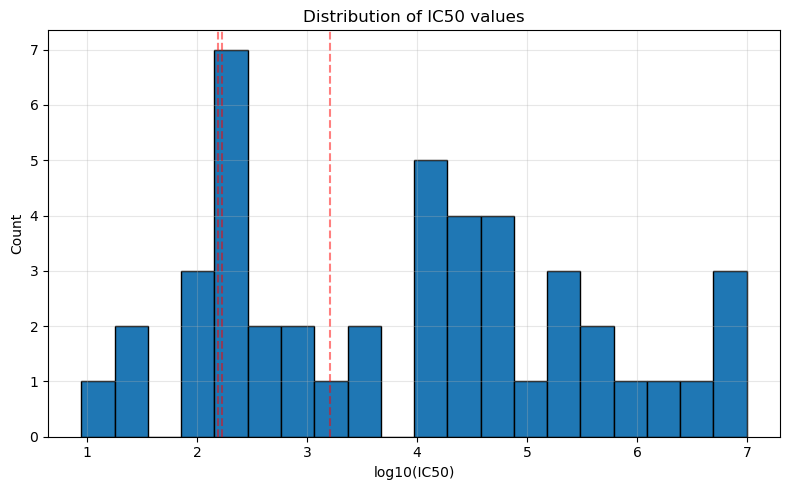

In [217]:
import numpy as np
import matplotlib.pyplot as plt

vals = ic50_table.values.flatten()[:-3]
vals = vals[~np.isnan(vals)]

plt.figure(figsize=(8, 5))
plt.hist(vals, bins=20, edgecolor='black')

for v in (vals[-3:]):
    plt.axvline(v, color='red', linestyle='--', alpha=0.5)

plt.xlabel('log10(IC50)')
plt.ylabel('Count')
plt.title('Distribution of IC50 values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

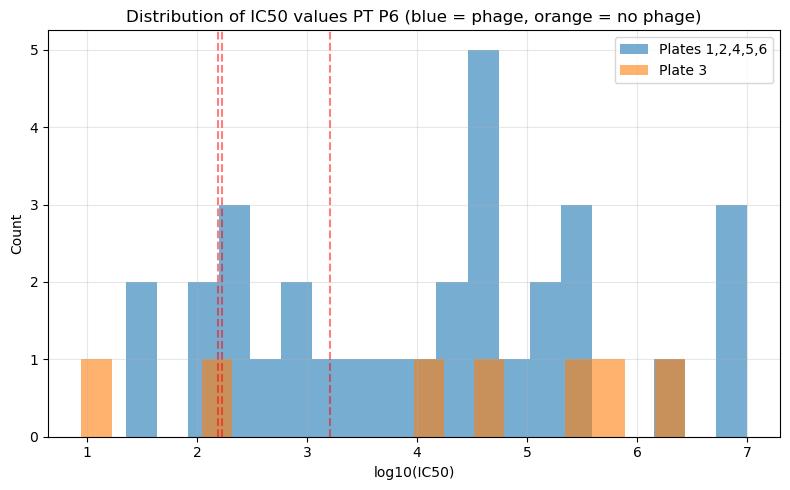

In [218]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten by plate groups
group1_plates = [1,2,4,5,6]
group2_plates = [3]

group1_vals = ic50_table.loc[group1_plates].values.flatten()
group2_vals = ic50_table.loc[group2_plates].values.flatten()

# Remove NaNs
group1_vals = group1_vals[~np.isnan(group1_vals)]
group2_vals = group2_vals[~np.isnan(group2_vals)]

plt.figure(figsize=(8, 5))

# Histograms
plt.hist(group1_vals, bins=20, alpha=0.6, label='Plates 1,2,4,5,6')
plt.hist(group2_vals, bins=20, alpha=0.6, label='Plate 3')

# Highlight last 3 values (still works)
vals = ic50_table.values.flatten()
vals = vals[~np.isnan(vals)]

for v in vals[-3:]:
    plt.axvline(v, color='red', linestyle='--', alpha=0.5)

plt.xlabel('log10(IC50)')
plt.ylabel('Count')
plt.title('Distribution of IC50 values PT P6 (blue = phage, orange = no phage)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [211]:
np.array(ic50_table.iloc[[3]])

array([[4.54930059, 5.87557745, 4.21963782, 6.43909788, 2.24729157,
        5.50724456, 0.94989606]])